### Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

products = pd.read_csv("products_features.csv")
master_df = pd.read_csv("master_dataset.csv")

### Product KPIs

In [2]:
total_products = products["product_id"].nunique()

total_categories = products["category"].nunique()

total_brands = products["brand"].nunique()

average_price = products["price"].mean()

average_discount = products["Discount_Percentage"].mean()

In [3]:
print(f"Total Products : {total_products}")
print(f"Total Categories : {total_categories}")
print(f"Total Brands : {total_brands}")
print(f"Average Price : ₹{average_price:.2f}")
print(f"Average Discount : {average_discount:.2f}%")

Total Products : 268
Total Categories : 11
Total Brands : 267
Average Price : ₹488.36
Average Discount : 27.78%


### Product Sales Analysis

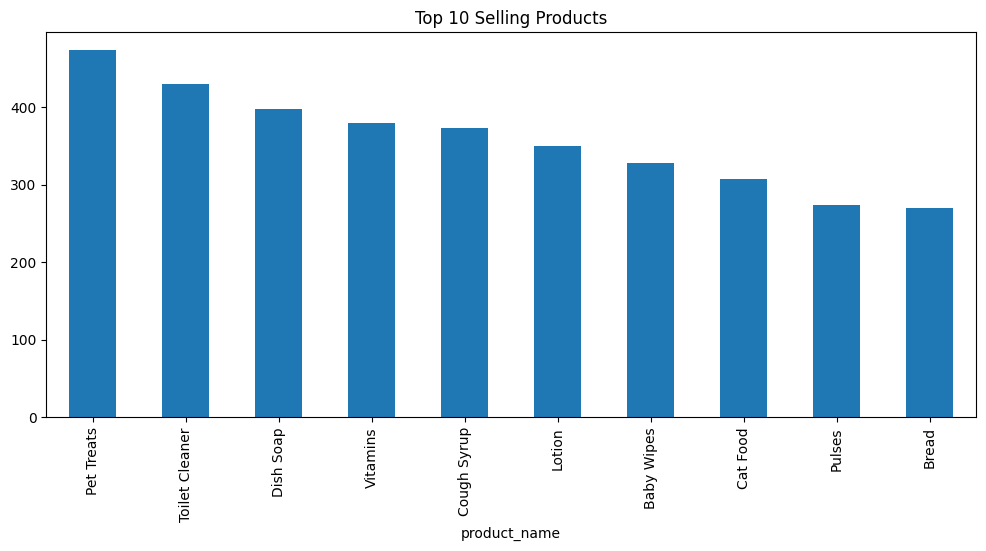

In [4]:
top_products = master_df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar',figsize=(12,5))
plt.title("Top 10 Selling Products")
plt.show()

### Business Question

Which products contribute the highest sales volume?

### Observation

Pet Treats contribute the highest sales volume and Top 10 selling products have been recorded.

### Recommendation

Increase inventory for high-demand products.

### Business Impact

Improves product availability and reduces stockouts.

### Category Performance

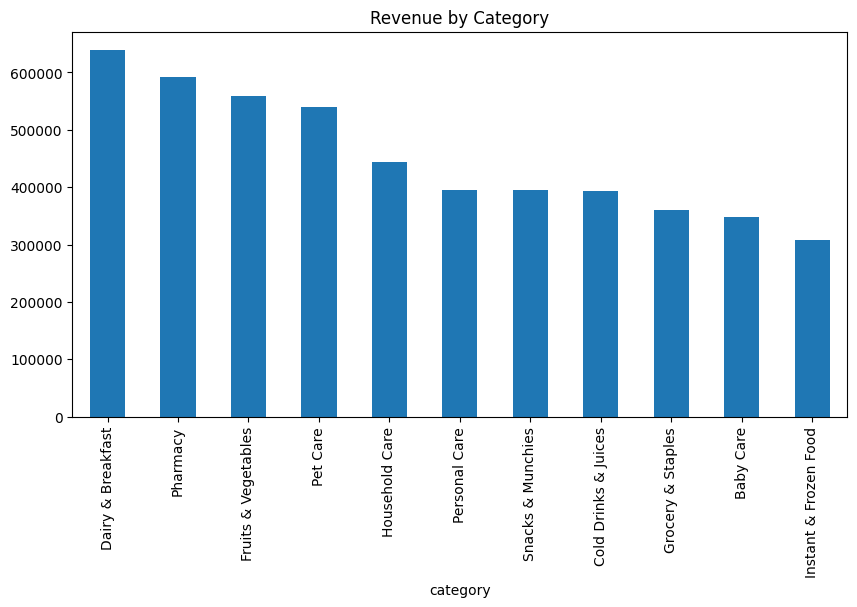

In [6]:
category_revenue = master_df.groupby('category')['Revenue'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar',figsize=(10,5))
plt.title("Revenue by Category")
plt.show()

### Business Question
Which product Category contribute the highest Revenue?

### Observation
Dairy and Breakfast Category contributes the highest revenue and Revenue by categories are recorded.

### Recommendation
Increase inventory for high-demand categories.

### Business Impact
Improves product availability and reduces stockouts.

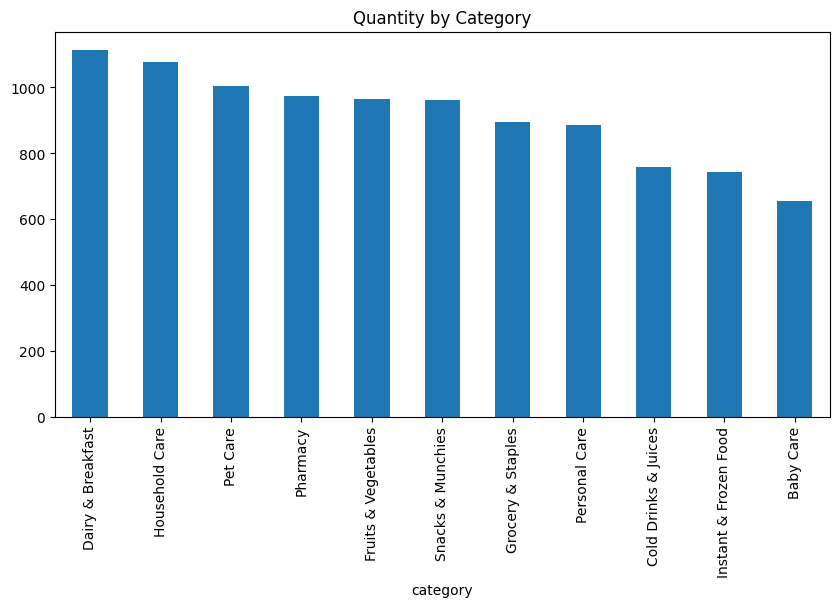

In [7]:
category_quantity = master_df.groupby('category')['quantity'].sum().sort_values(ascending=False)

category_quantity.plot(kind='bar',figsize=(10,5))
plt.title("Quantity by Category")
plt.show()

### Business Question
Which product Category contribute the highest Sales Volume?

### Observation
Dairy and Breakfast Category contributes the highest Sales Volume and Lowest Performing Category is Baby Care.

### Recommendation
Increase inventory for high-demand categories.

### Business Impact
Improves product availability and reduces stockouts.

### Brand Performance

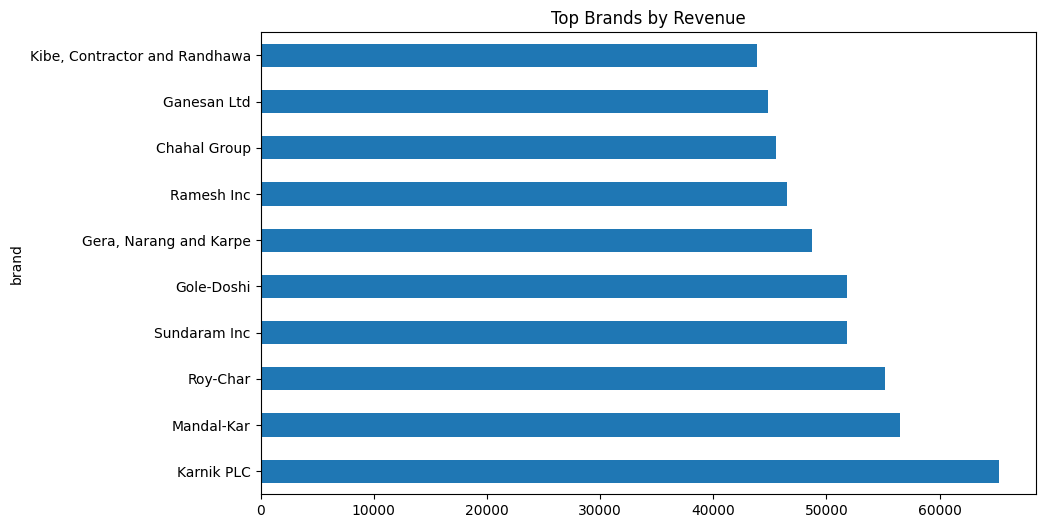

In [10]:
brand_sales = (master_df.groupby("brand")["Revenue"].sum().sort_values(ascending=False).head(10))

brand_sales.plot(kind="barh",figsize=(10,6))
plt.title("Top Brands by Revenue")
plt.show()

### Business Question
Which brand contribute the highest revenue?

### Observation
Karnik PLC Brand contributes the highest revenue and should receive more shelf space.

### Recommendation
Increase inventory for high-demand brands.

### Business Impact
Improves product availability and reduces stockouts.

### Discount Analysis

In [11]:
products["Discount_Percentage"].describe()

count    268.000000
mean      27.779930
std        7.458682
min       14.996496
25%       20.000264
50%       29.999386
75%       34.999881
max       40.000852
Name: Discount_Percentage, dtype: float64

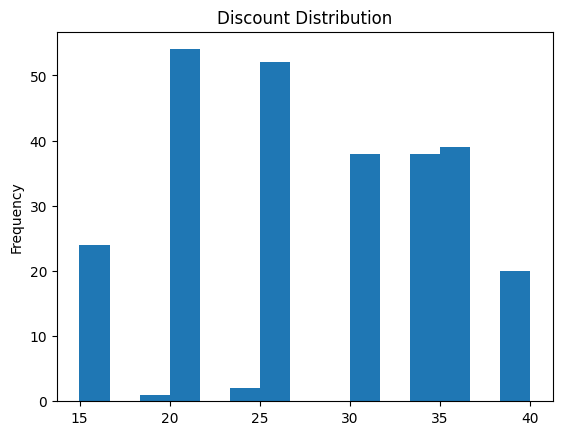

In [12]:
products["Discount_Percentage"].plot(kind="hist",bins=15)
plt.title("Discount Distribution")
plt.show()

In [13]:
master_df.groupby("Price_Category")["Revenue"].sum()

Price_Category
High        854116.06
Low         482259.85
Medium      855296.98
Premium    2780742.54
Name: Revenue, dtype: float64

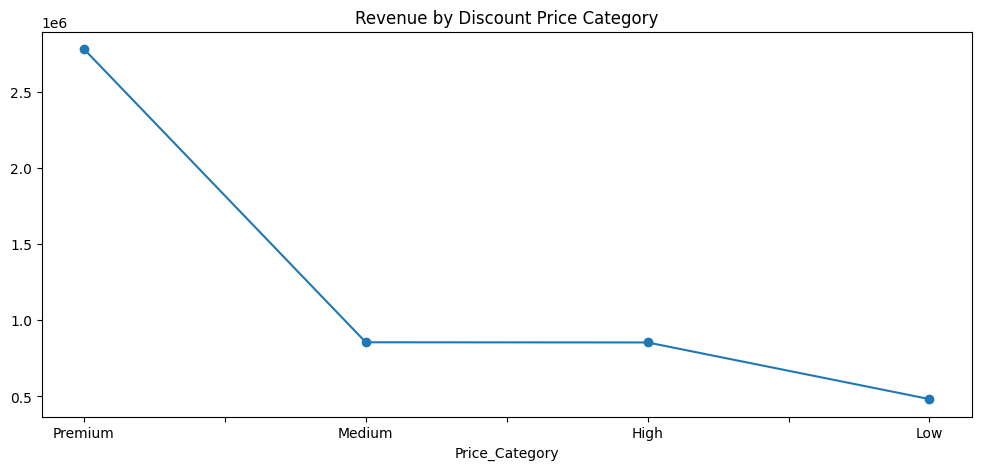

In [16]:
master_df.groupby("Price_Category")["Revenue"].sum().sort_values(ascending=False).plot(kind='line',marker='o',figsize=(12,5))
plt.title("Revenue by Discount Price Category")
plt.show()

### Business Question
Do discounts influence sales? Do highly discounted products sell better?

### Observation
Yes, Discounts influence sales and highly discounted products sell better.

### Recommendation
Increase discount for high-demand products and best selling categories.

### Business Impact
Improves product availability and reduces stockouts.

### Price Category Analysis

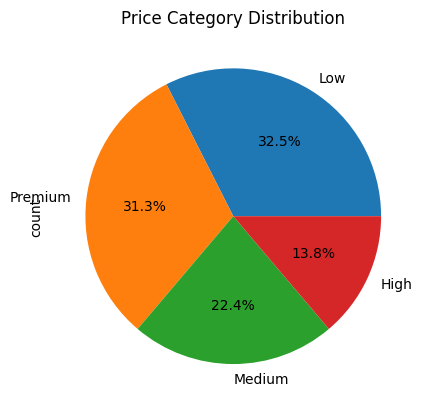

In [17]:
products["Price_Category"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Price Category Distribution")
plt.show()

### Business Question
Which price category has the most products?

### Observation
Low price and Premium Price categories has the most products.

### Recommendation
Maintain discount for high-demand products and increase discount for best selling categories.

### Business Impact
Improves product availability and reduces stockouts.

### Product Revenue Analysis

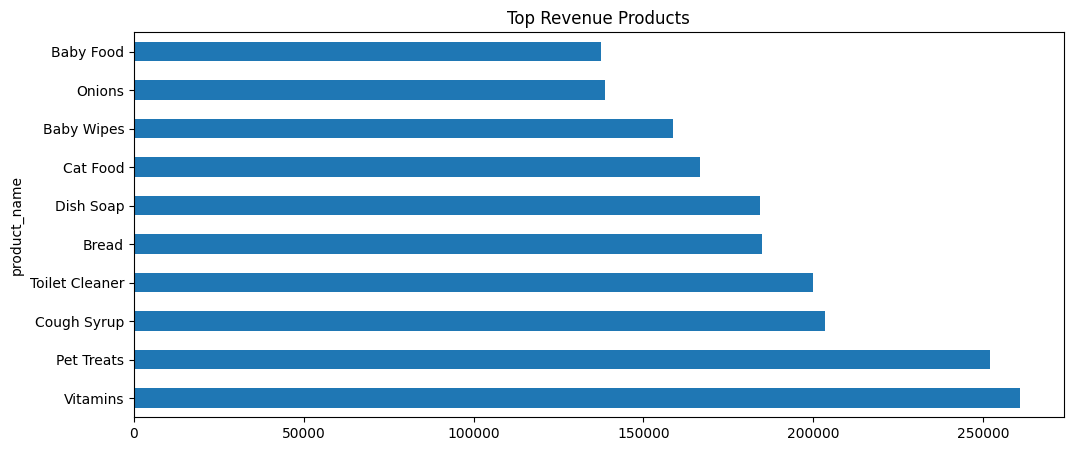

In [18]:
product_revenue = (master_df.groupby("product_name")["Revenue"].sum().sort_values(ascending=False).head(10))

product_revenue.plot(kind="barh",figsize=(12,5))
plt.title("Top Revenue Products")
plt.show()

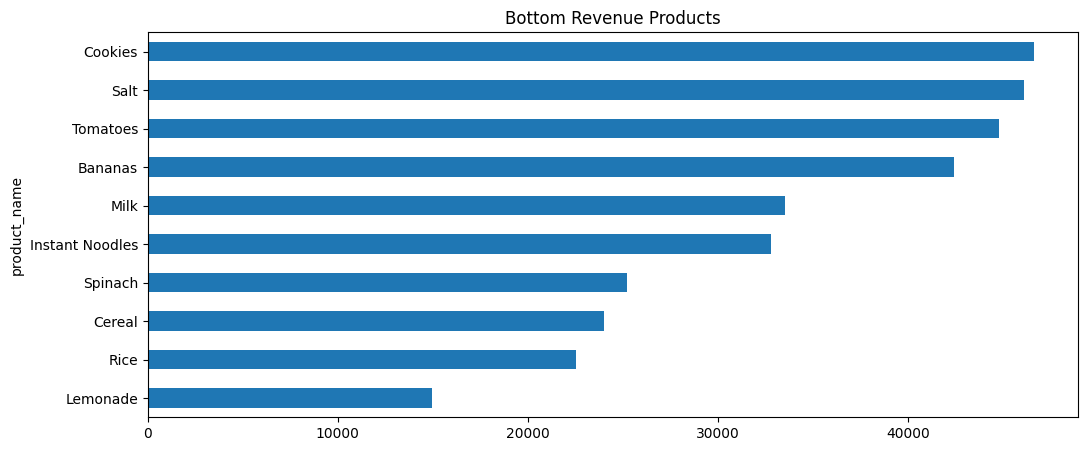

In [19]:
product_revenue = (master_df.groupby("product_name")["Revenue"].sum().sort_values().head(10))

product_revenue.plot(kind="barh",figsize=(12,5))
plt.title("Bottom Revenue Products")
plt.show()

In [20]:
master_df.groupby("product_name")["Revenue"].sum().max()

260822.01

In [21]:
master_df.groupby("product_name")["Revenue"].sum().min()

14977.8

### Business Question
Which products should be promoted? Which products should be reviewed or phased out?

### Observation
Vitamins and Pet Treats contributes highest revenue and Lemonade contributes the lowest revenue.

### Recommendation
Top Revenue products should be promoted and Bottom Revenue products should be reviewed or phased out.

### Business Impact
Improves product availability and reduces stockouts.

### Product Correlation Analysis

In [26]:
master_df[["Revenue","Discount_Percentage"]].corr()

,Revenue,Discount_Percentage
Revenue,1.000000,-0.056186
Discount_Percentage,-0.056186,1.000000


In [24]:
master_df[["price","quantity"]].corr()

,price,quantity
price,1.000000,0.019686
quantity,0.019686,1.000000


### Business Question
Does higher price reduce quantity sold? 
Does higher discount increase revenue?

### Observation
No, because we have a slight positive correlation between price and quantity.
No, because we have a slight negative correation between discount and revenue.

### Outlier Detection

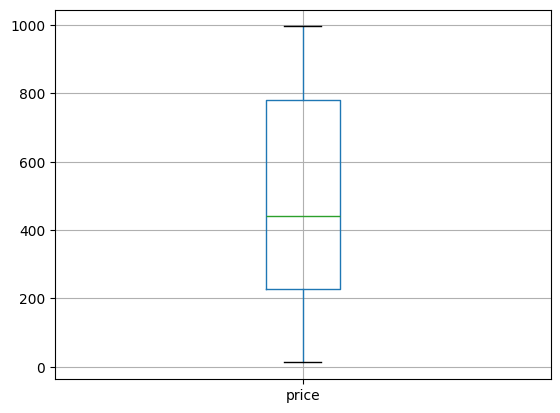

In [27]:
products.boxplot(column="price")
plt.show()

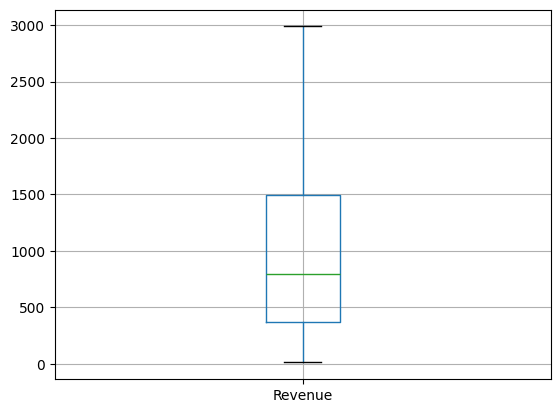

In [28]:
master_df.boxplot(column="Revenue")
plt.show()

### Business Question
Are there unusually expensive products?
Are a few products generating most of the revenue?

### Observation
There are no unusually expensive products and few products are not only generating most of the revenue.

## Dashboard Requirements

### KPIs
- Total Products
- Total Categories
- Total Brands
- Total Revenue
- Average Discount %

### Charts
- Top 10 Products
- Revenue by Category
- Revenue by Brand
- Discount Distribution
- Price Category Distribution
- Top Revenue Products

### Filters (Slicers)
- Category
- Brand
- Price Category
- Date